# Online Retail Customer Analysis Project

#### Understanding the Data

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df=pd.read_csv('data/online_retail_II.csv',parse_dates=['InvoiceDate'])

print("Fist 5 rows of the dataset:")
print(df.head())

print("\nData size: ", df.shape)

print("\nColumns: ")
print(df.columns.tolist())

print("\nMissing values: ")
print(df.isnull().sum())

print("\nDuplicate rows: ")
print(df.duplicated().sum())

print("\nData info: ")
print(df.info())

print("\nDescriptive statistics: ")
print(df.describe())

## Quantity and Price columns have negative min values, which may indicate returns or errors in the data. 
print ("\n How many negative records are there for Quantity and Price?")
print((df['Quantity'] < 0).sum())
print((df['Price'] < 0).sum())

print("\n is there any product with zero price?")
print((df['Price'] == 0).sum())

print("\n is there any product with zero quantity?")
print((df['Quantity'] == 0).sum())

#We need to find cancelled orders, which are usually indicated by Invoice numbers starting with 'C'(cancellation).
print("\nNumber of cancelled orders: ")
print(df['Invoice'].astype(str).str.startswith('C').sum())

Fist 5 rows of the dataset:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

Data size:  (1067371, 8)

Columns: 
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Missing values: 
Invoice             0
StockCode   

#### Data Cleaning and Processing


In [30]:
#Deleting the duplicates, rows with null and negative values in Quantity and Price columns.

df_cleaned = df.drop_duplicates()
df_cleaned = df_cleaned.dropna(subset=['Customer ID', 'Description'])

#Removing negative quantities but only the ones that are not cancelled orders, as they may represent returns.
df_cleaned = df_cleaned[(df_cleaned['Quantity'] > 0) & (df_cleaned['Invoice'].astype(str).str.startswith('C')==False)]
df_cleaned = df_cleaned[df_cleaned['Price'] > 0]

print("\nCleaned data size: ", df_cleaned.shape)

#Check
print("\nMissing values after cleaning: ")
print(df_cleaned.isnull().sum())

print("\nDuplicate rows after cleaning: ")
print(df_cleaned.duplicated().sum())    

#We also need to seperate the cancelled orders for further analysis.
df_cancelled=df[(df['Invoice'].astype(str).str.startswith('C'))] 
print(df_cancelled.shape)


#We need to create a new column 'TotalPrice' which is the product of Quantity and Price for each transaction.
df_cleaned['TotalPrice'] = df_cleaned['Quantity'] * df_cleaned['Price']
print("\nFirst 5 rows of the cleaned dataset with TotalPrice: ") 
print(df_cleaned[['Quantity', 'Price', 'TotalPrice']].head())


Cleaned data size:  (779425, 8)

Missing values after cleaning: 
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

Duplicate rows after cleaning: 
0
(19494, 8)

First 5 rows of the cleaned dataset with TotalPrice: 
   Quantity  Price  TotalPrice
0        12   6.95        83.4
1        12   6.75        81.0
2        12   6.75        81.0
3        48   2.10       100.8
4        24   1.25        30.0


#### EDA

##### Montly Sales Trend

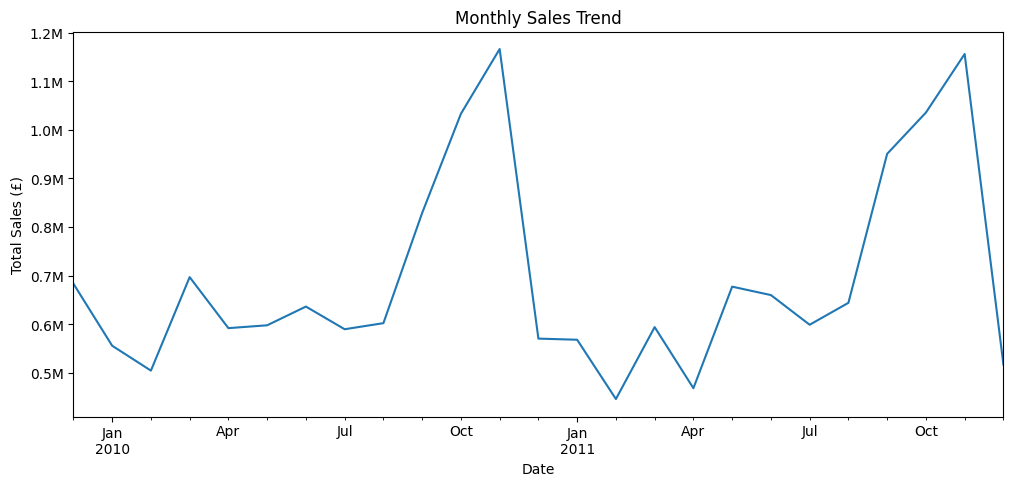

In [31]:
#Monthly Sales Trend
monthly_sales = df_cleaned.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
plt.ylabel('Total Sales (£)')
plt.show()



##### Top 10 Products

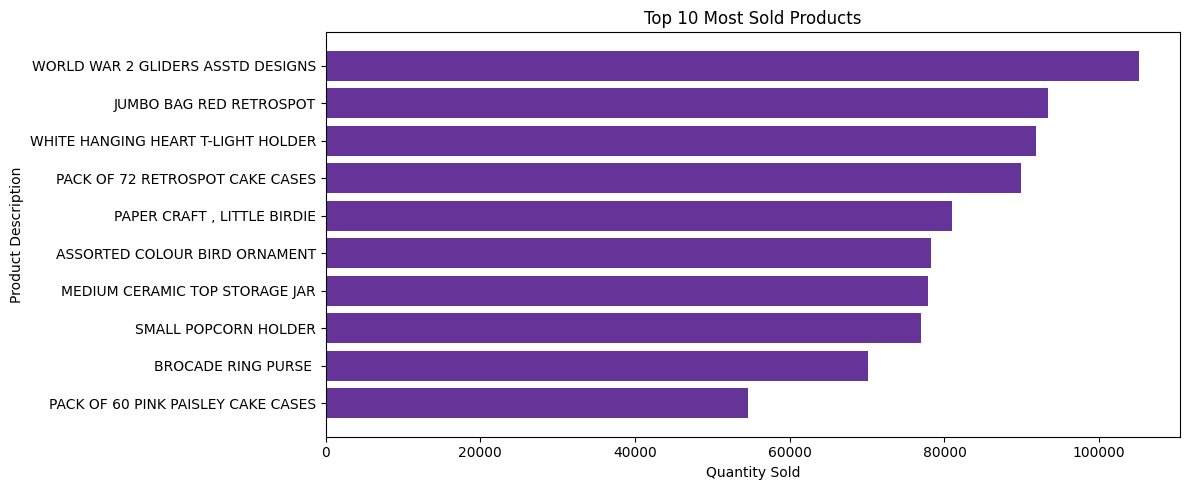

In [32]:
#10 Most Sold Products
top_products=df_cleaned.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(10)
description_mapping=df_cleaned.groupby('StockCode')['Description'].agg(lambda x: x.mode()[0])

#description_mapping.head(10)

top_products_df =top_products.reset_index() #We are resetting the index and turning top_products series into a dataframe to merge it with the description_mapping dataframe.
top_10_merged = pd.merge(top_products_df, description_mapping, on='StockCode', how='left')
top_10_merged.head(10)

#Plotting the top 10 most sold products
plt.figure(figsize = (12,5))
plt.barh(top_10_merged['Description'],top_10_merged['Quantity'],color='rebeccapurple')
plt.gca().invert_yaxis() #To display the highest sold product at the top
plt.title('Top 10 Most Sold Products')
plt.xlabel('Quantity Sold')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

#### Top 10 Country  

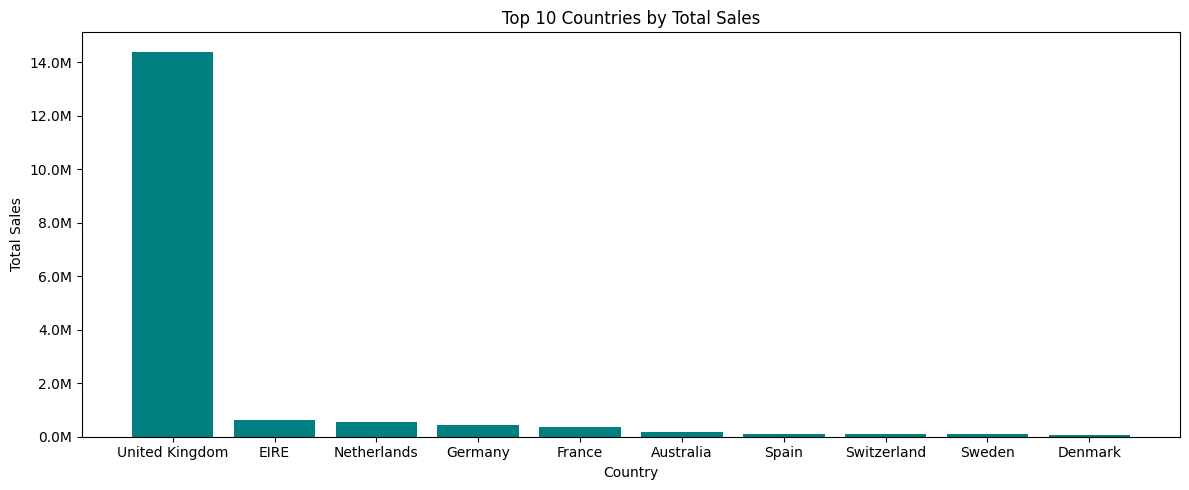

In [42]:
top_countries = df_cleaned.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)


plt.figure(figsize = (12,5))
plt.bar(top_countries.index, top_countries.values, color='teal')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()


#### Customer Spending Distribution

Text(0, 0.5, 'Number of Customers')

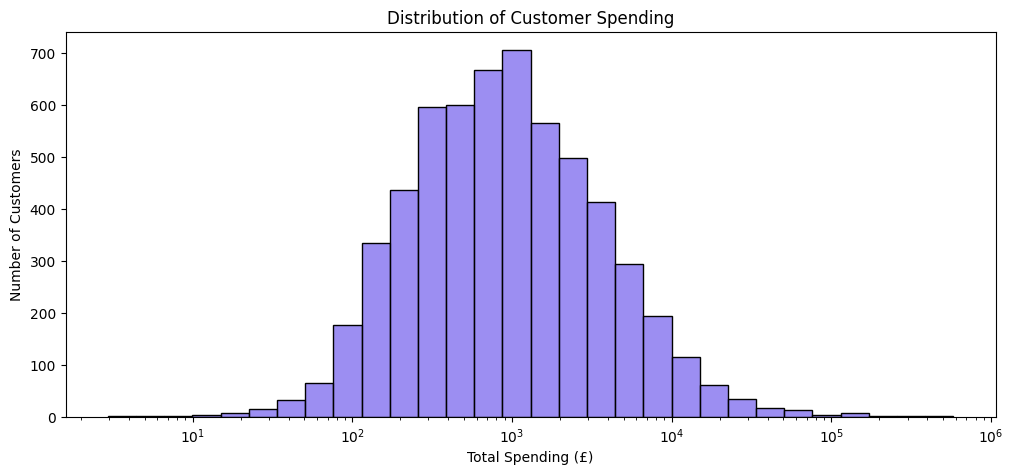

In [62]:
customer_spending = df_cleaned.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False)
plt.figure(figsize = (12,5))
plt.xscale('log')
sns.histplot(customer_spending,bins =30, color='mediumslateblue')
plt.title('Distribution of Customer Spending')
plt.xlabel('Total Spending (£)')
plt.ylabel('Number of Customers')


#### Outlier Analysis